# Day-Ahead Price Forecasting — Linear Baseline Models

Day-ahead electricity prices in the German-Luxembourg bidding zone (DE-LU) are among the most volatile in Europe, shaped by renewable intermittency, cross-border flows, and commodity markets. Accurate forecasts directly inform trading, grid balancing, and hedging decisions.

This notebook benchmarks four forecasting approaches on five years of hourly market data (January 2021 – present) using a strict walk-forward evaluation: models are trained only on data available at the time of forecast, with no look-ahead.

**Models evaluated:**
| Model | Type | Description |
|---|---|---|
| SimilarDay (Naive) | Rule-based | Reuses the price from the same hour one or seven days earlier |
| Lasso | Linear, L1 regularisation | Shrinks irrelevant feature weights to exactly zero — built-in feature selection |
| Ridge | Linear, L2 regularisation | Shrinks all weights smoothly — retains all features |
| OLS | Linear, no regularisation | Ordinary least squares — unconstrained linear fit |

**Conclusion:** All three linear models perform similarly as expected when n>>p. **Lasso** is selected as the linear baseline because L1 regularisation makes the model self-documenting: the zero weights explicitly confirm which features carry no predictive signal.

In [1]:
from pathlib import Path

import mlflow
import pandas as pd

from energy_price_forecast.evaluation.config import EXPERIMENT_NAME

c:\Users\soent\dev\energy-price-forecast\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Backtest Results

In [2]:
mlflow.set_tracking_uri("file:../mlruns")

runs = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["start_time DESC"],
)

# Keep only the most recent run per run_name.
latest = runs.drop_duplicates(subset="tags.mlflow.runName", keep="first").set_index(
    "tags.mlflow.runName"
)

# Alias the most recent <model>_* run for each linear model so downstream cells use short names.
_run_aliases: dict[str, str] = {}
for _model in ("lasso", "ridge", "ols"):
    _model_runs = latest[latest.index.str.startswith(f"{_model}_")]
    if not _model_runs.empty:
        _original = _model_runs.index[0]
        _run_aliases[_model] = _original
        latest = latest[~latest.index.isin([_model])].rename(index={_original: _model})

for name in ("similarday_naive", "lasso", "ridge", "ols"):
    if name not in latest.index:
        raise RuntimeError(
            f"Run '{name}' not found in experiment '{EXPERIMENT_NAME}'. "
            "Run scripts/backtest.py for this model first."
        )

print(f"naive  run: {latest.loc['similarday_naive', 'run_id']}")
for _m in ("lasso", "ridge", "ols"):
    print(f"{_m:6s} run: {latest.loc[_m, 'run_id']}  (run name: {_run_aliases.get(_m, _m)})")

c:\Users\soent\dev\energy-price-forecast\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


naive  run: bbe69fa5b01e425880d9b73391cdf800
lasso  run: bf5ecbb8874e416c870fb8f3a43235a7  (run name: lasso_identity)
ridge  run: c7bf09ed48a146828b67dafe9f637bf4  (run name: ridge_identity)
ols    run: 9680893e1ca54f45a08df287a016659e  (run name: ols_identity)


## 2. Test Period Validation

All four models must have been evaluated on the same test period and delivery days before they can be compared fairly.

In [3]:
def _param(run_name: str, col: str) -> str:
    return str(latest.loc[run_name, f"params.{col}"])


naive_start = _param("similarday_naive", "test_start")
naive_end = _param("similarday_naive", "test_end")

all_ok = True
for _m in ("lasso", "ridge", "ols"):
    m_start, m_end = _param(_m, "test_start"), _param(_m, "test_end")
    if m_start != naive_start or m_end != naive_end:
        print(f"WARNING: {_m} window ({m_start}, {m_end}) differs from naive ({naive_start}, {naive_end})")
        all_ok = False

if all_ok:
    print(f"Test period: {naive_start} to {naive_end}  [all models aligned]")

Test period: 2021-01-01 to None  [all models aligned]


In [4]:
def _load_predictions(run_name: str) -> pd.DataFrame:
    run_id = latest.loc[run_name, "run_id"]
    client = mlflow.tracking.MlflowClient()
    artifacts = client.list_artifacts(run_id)
    parquet_files = [a.path for a in artifacts if a.path.endswith(".parquet")]
    if not parquet_files:
        raise FileNotFoundError(f"No parquet artifact found for run '{run_name}' ({run_id}).")
    local_path = client.download_artifacts(run_id, parquet_files[0])
    return pd.read_parquet(local_path)


preds_naive = _load_predictions("similarday_naive")
preds_lasso = _load_predictions("lasso")
preds_ridge = _load_predictions("ridge")
preds_ols = _load_predictions("ols")

days_ref = set(preds_naive["delivery_day"].unique())
for _name, _preds in (("lasso", preds_lasso), ("ridge", preds_ridge), ("ols", preds_ols)):
    _days = set(_preds["delivery_day"].unique())
    if _days != days_ref:
        print(f"WARNING: {_name} delivery days differ ({len(_days)} vs {len(days_ref)} for naive)")
    else:
        print(f"{_name:6s}: {len(_days)} delivery days  [OK]")

lasso : 1826 delivery days  [OK]
ridge : 1826 delivery days  [OK]
ols   : 1826 delivery days  [OK]


## 3. Model Comparison

MAE (Mean Absolute Error) and RMSE are in EUR/MWh. WAPE (Weighted Absolute Percentage Error) is dimensionless. The `_vs_naive_%` columns show the relative improvement over the rule-based benchmark — negative values mean better performance.

In [5]:
METRIC_COLS = [
    "metrics.mae",
    "metrics.rmse",
    "metrics.wape",
    "metrics.mae_per_day_mean",
    "metrics.mae_per_day_std",
    "metrics.mae_per_day_p05",
    "metrics.mae_per_day_p50",
    "metrics.mae_per_day_p95",
]

MODEL_LABELS = {
    "similarday_naive": "SimilarDay (Naive)",
    "lasso": "Lasso",
    "ridge": "Ridge",
    "ols": "OLS",
}

table = latest.loc[list(MODEL_LABELS.keys()), METRIC_COLS].copy()
table.columns = [c.replace("metrics.", "") for c in table.columns]
table.index = [MODEL_LABELS[i] for i in table.index]
table.index.name = "model"
table = table.astype(float)

naive_val = table.loc["SimilarDay (Naive)"]
for col in ("mae", "rmse"):
    table[f"{col}_vs_naive_%"] = (table[col] - naive_val[col]) / naive_val[col] * 100

table.round(3)

,mae,rmse,wape,mae_per_day_mean,mae_per_day_std,mae_per_day_p05,mae_per_day_p50,mae_per_day_p95,mae_vs_naive_%,rmse_vs_naive_%
model,,,,,,,,,,
SimilarDay (Naive),34.771,56.196,0.290,34.762,35.277,5.626,23.399,100.614,0.000,0.000
Lasso,24.230,38.398,0.202,24.227,22.910,5.571,17.430,66.003,-30.317,-31.670
Ridge,24.254,38.408,0.202,24.251,22.873,5.366,17.441,66.064,-30.248,-31.654
OLS,24.254,38.408,0.202,24.252,22.872,5.365,17.437,66.066,-30.247,-31.654


## 4. Feature Importance

The walk-forward harness refits each model every seven days, so there is no single coefficient snapshot. For interpretability, we fit each model once on all pre-test data and inspect the resulting weights. Coefficients are in **standardised feature space** (after `StandardScaler`), so magnitudes are directly comparable across features.

Lasso's L1 penalty drives unimportant weights to exactly zero — the non-zero features are the ones the model actually uses.

In [ ]:
from energy_price_forecast.data.loaders import load_interim_hourly, load_processed_features
from energy_price_forecast.models.baseline import LassoForecaster, OLSForecaster, RidgeForecaster
from pathlib import Path
import warnings

test_start = pd.Timestamp(_param("lasso", "test_start"), tz="UTC")

price = load_interim_hourly(Path("../data/interim/hourly.parquet"))["day_ahead_price"]
features = load_processed_features(Path("../data/processed/features.parquet"))

y_all = price.reindex(features.index)
train_mask = features.index < test_start

coef_dict: dict[str, pd.Series] = {}
alpha_info: dict[str, str] = {}
for _label, _model in [
    ("Lasso", LassoForecaster(cv_splits=5, target_transform="identity")),
    ("Ridge", RidgeForecaster(target_transform="identity")),
    ("OLS", OLSForecaster(target_transform="identity")),
]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _model.fit(y_all[train_mask], features[train_mask])
    coef_dict[_label] = pd.Series(_model._pipeline[-1].coef_, index=_model._columns)
    if hasattr(_model._pipeline[-1], "alpha_"):
        alpha_info[_label] = f"alpha={_model._pipeline[-1].alpha_:.4f}"
    else:
        alpha_info[_label] = "no regularisation"

coef_df = pd.DataFrame(coef_dict)
coef_df["_abs_lasso"] = coef_df["Lasso"].abs()
coef_df = coef_df.sort_values("_abs_lasso", ascending=False).drop(columns="_abs_lasso")

n_nonzero = (coef_df["Lasso"] != 0).sum()
print(f"Lasso: {n_nonzero}/{len(coef_df)} features retained  ({alpha_info['Lasso']})")
print(f"Ridge: all {len(coef_df)} features retained          ({alpha_info['Ridge']})")
print(f"OLS:   all {len(coef_df)} features retained          ({alpha_info['OLS']})\n")
display(coef_df.round(4))

Lasso: 22/34 features retained  (alpha=0.1263)
Ridge: all 34 features retained          (alpha=1.0000)
OLS:   all 34 features retained          (no regularisation)



,Lasso,Ridge,OLS
residual_load_forecast,8.4998,10.3689,14.3319
renewable_share_forecast,-2.7001,-4.1990,-4.1649
month_sin,-2.5957,-2.4383,-2.4376
price_lag_24h,2.5838,3.1758,3.1751
price_lag_168h,2.1437,1.9599,1.9564
load_actual_lag_168h,1.4027,1.9105,1.8653
scheduled_net_export_lag_24h,1.2233,1.5140,1.5176
load_forecast_error_lag_48h,1.0170,1.2596,1.2616
month_cos,-0.8989,-0.7851,-0.7863
price_lag_48h,0.4011,1.4152,1.4187


## 5. Error Analysis by Market Regime

Electricity markets have passed through three structurally distinct periods since 2021. We segment errors accordingly to check whether model accuracy holds across regimes:

- **Calm** (before Sep 2021): low and stable prices, moderate volatility
- **Energy crisis** (Sep 2021 – Apr 2023): gas price shock drove DA prices to record highs, with extreme intraday swings
- **Post-crisis** (from Apr 2023): prices normalised but remain structurally higher than the pre-crisis period

A positive mean error means the model over-predicted (forecast too high); negative means it under-predicted.

In [7]:
CRISIS_START = pd.Timestamp("2021-09-01", tz="UTC")
POST_CRISIS_START = pd.Timestamp("2023-04-01", tz="UTC")


def _regime(index: pd.DatetimeIndex) -> pd.Series:
    r = pd.Series("calm", index=index)
    r[index >= CRISIS_START] = "crisis"
    r[index >= POST_CRISIS_START] = "post-crisis"
    return r


def _error_stats(preds: pd.DataFrame, mask: pd.Series | None = None) -> dict[str, float]:
    df = preds.dropna(subset=["y_true", "y_pred"])
    if mask is not None:
        df = df[mask.reindex(df.index).fillna(False)]
    err = df["y_pred"] - df["y_true"]
    return {
        "mae": float(err.abs().mean()),
        "mean_error": float(err.mean()),
        "median_error": float(err.median()),
        "n_days": int(df["delivery_day"].nunique()),
    }


def _regime_table(preds: pd.DataFrame) -> pd.DataFrame:
    reg = _regime(pd.DatetimeIndex(preds.index))
    rows = {"overall": _error_stats(preds)}
    for name in ("calm", "crisis", "post-crisis"):
        rows[name] = _error_stats(preds, reg == name)
    return pd.DataFrame(rows).T[["mae", "mean_error", "median_error", "n_days"]]


for _label, _preds in [
    ("SimilarDay (Naive)", preds_naive),
    ("Lasso", preds_lasso),
    ("Ridge", preds_ridge),
    ("OLS", preds_ols),
]:
    print(f"\n=== {_label} ===")
    display(_regime_table(_preds).round(2))

print("\nPositive mean_error = model over-predicts; negative = under-predicts.")


=== SimilarDay (Naive) ===


,mae,mean_error,median_error,n_days
overall,34.77,0.29,-0.37,1826.0
calm,13.74,-1.51,-1.20,244.0
crisis,57.15,1.35,-0.10,578.0
post-crisis,27.01,0.12,-0.07,1006.0



=== Lasso ===


,mae,mean_error,median_error,n_days
overall,24.23,-3.16,-3.04,1826.0
calm,9.56,-5.41,-5.54,244.0
crisis,40.86,-3.32,-2.33,578.0
post-crisis,18.23,-2.53,-1.62,1006.0



=== Ridge ===


,mae,mean_error,median_error,n_days
overall,24.25,-2.83,-2.78,1826.0
calm,9.26,-4.99,-5.12,244.0
crisis,40.87,-2.74,-1.88,578.0
post-crisis,18.34,-2.35,-1.58,1006.0



=== OLS ===


,mae,mean_error,median_error,n_days
overall,24.25,-2.82,-2.78,1826.0
calm,9.26,-4.99,-5.13,244.0
crisis,40.87,-2.74,-1.89,578.0
post-crisis,18.34,-2.35,-1.57,1006.0



Positive mean_error = model over-predicts; negative = under-predicts.


The linear models outperform the similar day model in all periods.

## 6. Per-Day Error Distribution

Each box shows the spread of daily MAE values across the full test period. The median (centre line) reflects typical performance on an average day; the upper whisker and outliers show exposure to high-error days — typically driven by weather events or sudden demand spikes.

C:\Users\soent\AppData\Local\Temp\ipykernel_24400\467719498.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


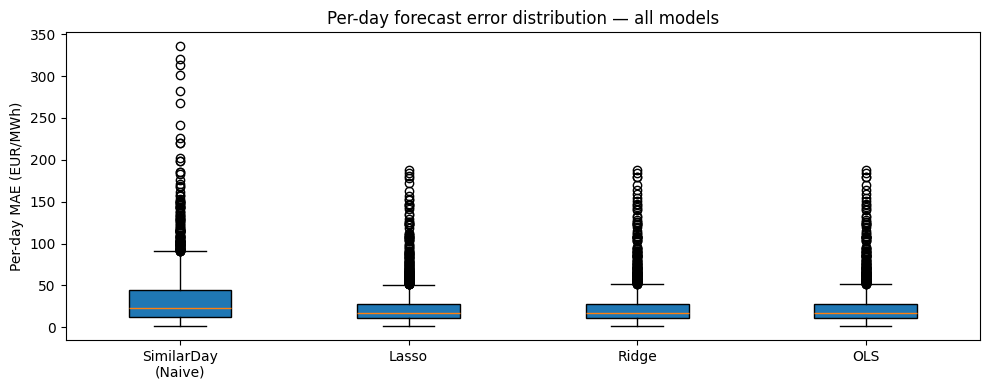

In [8]:
import matplotlib.pyplot as plt


def _per_day_mae(preds: pd.DataFrame) -> pd.Series:
    return (
        preds.dropna(subset=["y_true", "y_pred"])
        .assign(abs_err=lambda df: (df["y_true"] - df["y_pred"]).abs())
        .groupby("delivery_day")["abs_err"]
        .mean()
    )


mae_naive = _per_day_mae(preds_naive)
mae_lasso = _per_day_mae(preds_lasso)
mae_ridge = _per_day_mae(preds_ridge)
mae_ols = _per_day_mae(preds_ols)

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(
    [mae_naive.values, mae_lasso.values, mae_ridge.values, mae_ols.values],
    labels=["SimilarDay\n(Naive)", "Lasso", "Ridge", "OLS"],
    patch_artist=True,
)
ax.set_ylabel("Per-day MAE (EUR/MWh)")
ax.set_title("Per-day forecast error distribution — all models")
plt.tight_layout()
plt.show()

## 7. Forecast vs. Actual — Time Series View

Daily mean prices and Lasso forecasts plotted over the full test period. The energy crisis peak (winter 2021/22) and the subsequent normalisation are clearly visible.

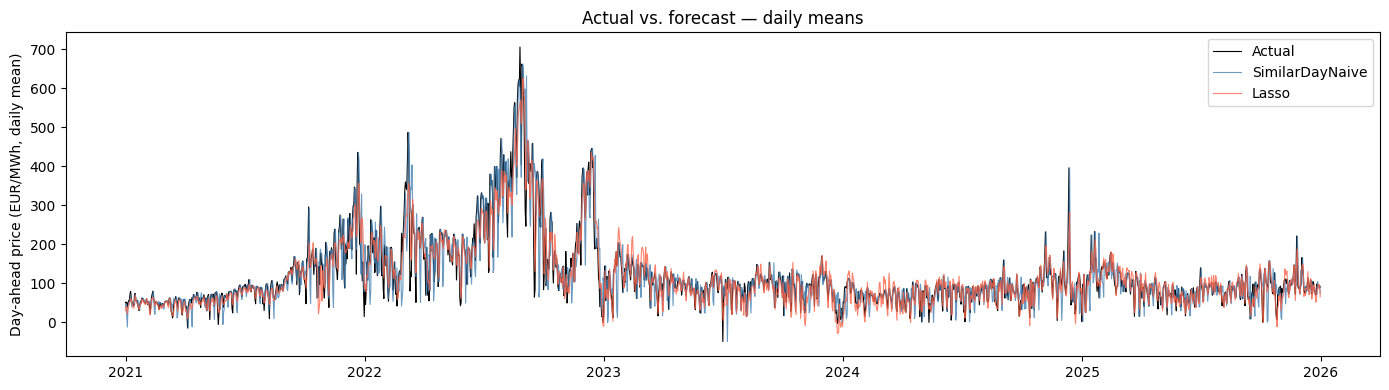

In [9]:
def _daily_means(preds: pd.DataFrame) -> pd.DataFrame:
    return (
        preds.dropna(subset=["y_true", "y_pred"])
        .resample("D")[["y_true", "y_pred"]]
        .mean()
    )


daily_naive = _daily_means(preds_naive)
daily_lasso = _daily_means(preds_lasso)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_naive.index, daily_naive["y_true"], color="black", linewidth=0.8, label="Actual")
ax.plot(daily_naive.index, daily_naive["y_pred"], color="steelblue", linewidth=0.8, alpha=0.8, label="SimilarDayNaive")
ax.plot(daily_lasso.index, daily_lasso["y_pred"], color="tomato", linewidth=0.8, alpha=0.8, label="Lasso")
ax.set_ylabel("Day-ahead price (EUR/MWh, daily mean)")
ax.set_title("Actual vs. forecast — daily means")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Summary and Next Steps

**Key findings:**

- All three regularised linear models (Lasso, Ridge, OLS) achieve similar accuracy, outperforming the rule-based benchmark by roughly 30% on MAE. This confirms that the engineered feature set carries real predictive signal.
- The linear models struggle most during the energy crisis (Sep 2021 – Apr 2023), where price dynamics were driven by gas supply shocks that lie outside the feature set's historical range — a structural challenge for any regression model.
- Lasso selects 22 of 34 features: **day-ahead load forecast** and **renewable share forecast** dominate, with further contributions from price lags and seasonality. The zeroed-out features are confirmed non-contributors under linear assumptions.
- A consistent negative bias (~3 EUR/MWh) across all linear models suggests the linear form cannot fully capture the asymmetric, right-skewed nature of electricity prices.

**Next stage:** A gradient-boosted tree model (LightGBM) will test whether non-linear interactions — particularly between renewable share and load — close the remaining gap. SHAP attribution will confirm whether the same drivers matter, or whether the tree discovers complementary signals.